# Implementing ANNs with TensorFlow - Homework 07 (Group 4)

## Assignment: Implement LSTM



### Load the dataset

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import datetime
%load_ext tensorboard

# load the data
(train_ds, test_ds), ds_info = tfds.load("mnist", split=["train", "test"], as_supervised=True, with_info=True)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to ~/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### Prepare the dataset

In [2]:
def prepare_data(mnist, batch_size=32, seq_len=4):
  """
  This function is used to prepare the raw data for training and testing.

  Arguments:
  mnist -- (a subset of) the MNIST dataset
  batch_size -- denotes the batch size (default is 32)
  seq_len -- denotes the length of the subsequences (default is 4)
  """
  # convert images to float32 data type
  mnist = mnist.map(lambda img, target: (tf.cast(img, tf.float32), tf.cast(target, tf.dtypes.int32)))
  # normalize the data by projecting the pixel values into range [-1, 1]
  mnist = mnist.map(lambda img, target: (tf.cast(tf.image.per_image_standardization(img), tf.float32), target))
  # create subsequences
  mnist = mnist.window(seq_len)

  # define alternating scan function to create targets
  def alternating_scan_function(state, elem):
    # flip the sign for every element (state is the sign to use)
    new_state = state * (-1)
    # apply the appropriate sign to elem, which is the target of the element 
    new_elem = state * elem
    # return a tuple for the scan function: the new state and the output element
    return new_state, new_elem

  # apply this function via scanning, resulting in a dataset where the signs are alternating
  mnist = mnist.map(lambda img_seq, target_seq: (img_seq, target_seq.scan(initial_state=1, scan_func=alternating_scan_function)))

  # define helper function to apply cumulative sum to target sequence
  def cumsum_scan_function(state, elem):
    # state is the cumulative sum up the the current element, elem is the summand we add to it
    cumsum = state + elem
    # return a tuple of the calculated sum
    return cumsum, cumsum

  # apply the helper function to the subsequences, with a starting state of 0
  mnist = mnist.map(lambda img_seq, target_seq: (img_seq, target_seq.scan(initial_state=0, scan_func=cumsum_scan_function)))
  # finally we need to create a single element from everything in the subdataset
  mnist = mnist.map(lambda img_seq, target_seq: (img_seq.batch(seq_len).get_single_element(), target_seq.batch(seq_len).get_single_element()))
  
  # cache progress into memory
  mnist = mnist.cache()
  # shuffle the data into a random order
  mnist = mnist.shuffle(1000)
  # use batches of given size
  mnist = mnist.batch(batch_size)
  # prefetch as many data points as we put into a batch
  mnist = mnist.prefetch(tf.data.AUTOTUNE)

  return mnist

In [3]:
# apply the data preparation pipeline to the MNIST dataset
train_data = train_ds.apply(prepare_data)
test_data = test_ds.apply(prepare_data)

In [4]:
# check the shapes of the image and target sequences
for img_seq, target_seq in train_data.take(1):
  print("Shape of image sequences:", img_seq.shape)
  print("Shape of target sequences:", target_seq.shape)

Shape of image sequences: (32, 4, 28, 28, 1)
Shape of target sequences: (32, 4)


### The CNN model

In [5]:
class CNNModel(tf.keras.Model):
  """
  This class represents the CNN portion of our final model.
  """
  def __init__(self):
    """
    The constructor initiates the layers and their activation functions.
    """
    # call the parent constructor
    super().__init__()
    # use the Glorot Normal kernel initializer
    self.kernel_initializer = tf.keras.initializers.GlorotNormal()
    # add the respective convolutional, dropout, batch-norm, and pooling layers
    # pooling and batch-norm layers need to wrapped in TimeDistributed layers to process sequences correctly
    self.conv1 = tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=self.kernel_initializer)
    self.dropout = tf.keras.layers.Dropout(0.3)
    self.conv2 = tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=self.kernel_initializer)
    self.max_pool = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D(pool_size=2, strides=2))
    self.conv3 = tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=self.kernel_initializer)
    self.batch_norm = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())
    self.conv4 = tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=self.kernel_initializer)
    self.global_pool = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAvgPool2D())
    # create a list of the layers to simplify call function
    self.conv_layers = [self.conv1, self.dropout, self.conv2, self.max_pool, self.conv3, self.batch_norm, self.conv4, self.global_pool]

  @tf.function
  def call(self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    # feed the input through the network
    output = self.conv_layers[0](input)
    for layer in self.conv_layers[1:]:
      output = layer(output)

    return output

### The LSTM AbstractRNNCell layer

In [6]:
class CustomLSTMCell(tf.keras.layers.AbstractRNNCell):
  """
  This subclass of the AbstractRNNCell defines the LSTM cells of our final model.
  """
  def __init__(self, n_units=32):
    """
    The constructor defines the respective gates of the LSTM cell.

    Arguments:
    n_units -- denotes the number of output units (default is 32)
    """
    # call the parent constructor
    super().__init__()
    # store the number of units in the LSTM cell
    self.n_units = n_units
    # use the Orthogonal kernel initializer
    self.kernel_initializer = tf.keras.initializers.Orthogonal()
    # instantiate the gates using Dense layers
    self.forget_gate = tf.keras.layers.Dense(self.n_units,  kernel_initializer=self.kernel_initializer, activation='sigmoid')
    self.input_gate = tf.keras.layers.Dense(self.n_units, kernel_initializer=self.kernel_initializer, activation='sigmoid')
    self.cell_gate = tf.keras.layers.Dense(self.n_units, kernel_initializer=self.kernel_initializer, activation='tanh')
    self.output_gate = tf.keras.layers.Dense(self.n_units, kernel_initializer=self.kernel_initializer, activation='sigmoid')

  @property
  def state_size(self):
    """
    This function returns the state sizes of the LSTM cell.
    """
    return [tf.TensorShape([self.n_units]), tf.TensorShape([self.n_units])]

  @property
  def output_size(self):
    """
    This function returns the output size of the LSTM cell.
    """
    return [tf.TensorShape([self.n_units])]

  def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
    """
    This function determines the initial cell state and hidden state of the LSTM cell.

    Arguments are all set to None because else there is an issue with the model fit method.
    """
    return [tf.zeros([batch_size, self.n_units]), tf.zeros([batch_size, self.n_units])]

  @tf.function
  def call(self, input, states):
    """
    This function calls the model on new input.
    Returns the output of the LSTM, as well as a tuple of the new hidden and cell states.

    Arguments:
    input -- denotes the input tensors (a batch of feature vectors)
    states -- a list containing the hidden state and the cell state passed to the LSTM cell
    """
    # unpack the previous hidden and cell states
    hidden_state, cell_state = states
    # concatenate the input and the hidden state
    concat_input = tf.concat([input, hidden_state], axis=-1)
    # pass the input through the forget gate
    forget_update = self.forget_gate(concat_input)
    # pass the input through the input gate
    input_update = self.input_gate(concat_input)
    # pass the input through the cell gate
    cell_update = self.cell_gate(concat_input)
    # pass the input through the output gate
    output_update = self.output_gate(concat_input)
    # calculate the new cell state
    new_cell_state = forget_update * cell_state + input_update * cell_update
    # calculate the new hidden state
    new_hidden_state = output_update * tf.math.tanh(new_cell_state)
    
    return new_hidden_state, (new_hidden_state, new_cell_state)

### The RNN model

In [16]:
class RNNModel(tf.keras.Model):
  """
  This class combines the CNN model above with the defined LSTM cells to build a recurrent neural network.
  """
  def __init__(self):
    """
    The constructor initiates the layers and their activation functions.
    """
    # call the parent constructor
    super().__init__()
    # instantiate the CNN model
    self.conv = CNNModel()
    # instantiate the LSTM cell
    self.lstm = CustomLSTMCell()
    # create a recurrent layer using the LSTM cell (return full sequences)
    self.rnn = tf.keras.layers.RNN(self.lstm, return_sequences=True, unroll=False)
    # create the output layer
    self.output_layer = tf.keras.layers.Dense(1)

  @tf.function
  def call(self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    # feed the input through the network
    output = self.conv(input)
    output = self.rnn(output)
    output = self.output_layer(output)

    return output

### Visualization

In [21]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies):
  """
  This function visualizes the training progress by showing the MSE (loss) and MAE (accuracy) after each epoch.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  """
  # create the plot grid
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12,8))
  # plot training and test losses and accuracies
  line1, = axes[0].plot(train_losses, color="orange")
  line2, = axes[0].plot(test_losses, color="green")
  line3, = axes[1].plot(train_accuracies, color="orange")
  line4, = axes[1].plot(test_accuracies, color="green")
  # set the axis limits and labels
  axes[0].set(ylabel="Mean squared error")
  axes[1].set(xlabel="Training steps", ylabel="Mean absolute error")
  # create the legend
  axes[0].legend((line1, line2), ("Training","Test"))

  fig.suptitle("Training Progress")

  plt.show()

### Training the network

In [20]:
# hyperparameter for the training process
n_epochs = 10
# instantiate the RNN model
model = RNNModel()
# set the loss function, optimizer, and accuracy metric
loss_func = tf.keras.losses.MeanSquaredError()
optim = tf.keras.optimizers.Adam()
acc_metric = tf.keras.metrics.MeanAbsoluteError()
# configure the model for training (using MSE as loss function & Adam as our optimizer)
model.compile(loss=loss_func, optimizer=optim, metrics=[acc_metric])
# save logs of the model
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
logging_callback = tf.keras.callbacks.TensorBoard(log_dir=f".homework07/logs/{current_time}")
# train the model for the given number of epochs
history = model.fit(train_data, validation_data=test_data, epochs=n_epochs)

Epoch 1/10
469/469 [==============================] - 200s 421ms/step - loss: 20.3183 - mean_absolute_error: 3.5740 - val_loss: 13.6980 - val_mean_absolute_error: 2.9165
Epoch 2/10
469/469 [==============================] - 197s 420ms/step - loss: 8.1751 - mean_absolute_error: 2.1641 - val_loss: 4.9679 - val_mean_absolute_error: 1.6602
Epoch 3/10
469/469 [==============================] - 209s 445ms/step - loss: 3.6129 - mean_absolute_error: 1.3772 - val_loss: 3.0219 - val_mean_absolute_error: 1.2164
Epoch 4/10
469/469 [==============================] - 200s 425ms/step - loss: 2.6534 - mean_absolute_error: 1.1459 - val_loss: 2.4132 - val_mean_absolute_error: 1.0584
Epoch 5/10
469/469 [==============================] - 207s 441ms/step - loss: 2.2065 - mean_absolute_error: 1.0215 - val_loss: 2.1672 - val_mean_absolute_error: 0.9859
Epoch 6/10
469/469 [==============================] - 201s 429ms/step - loss: 1.8466 - mean_absolute_error: 0.9247 - val_loss: 1.8948 - val_mean_absolute_erro

In [ ]:
# save configs of the model
model.save(".homework07/configs/")

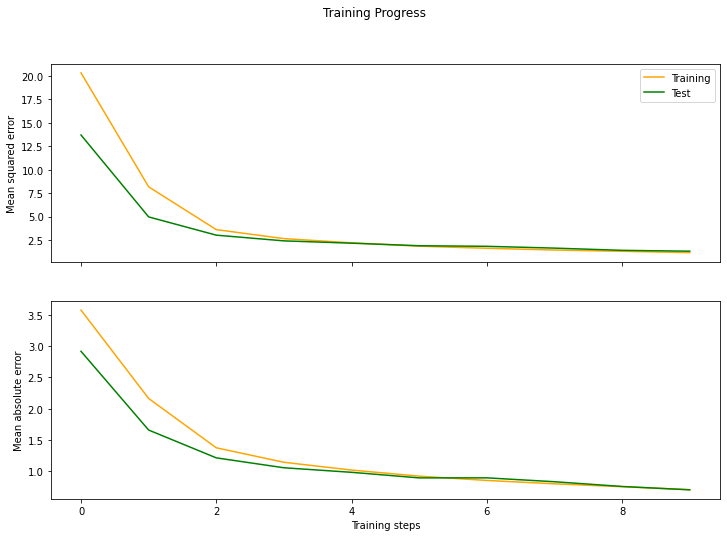

In [23]:
# unpack the model results
train_losses = history.history["loss"]
train_accuracies = history.history["mean_absolute_error"]
test_losses = history.history["val_loss"]
test_accuracies = history.history["val_mean_absolute_error"]
# visualize the results
visualization(train_losses, train_accuracies, test_losses, test_accuracies)